# **ЛАБОРАТОРНА РОБОТА 3**
## Decision Tree. Random Forest

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

## **1. Завантаження та підготовка даних (лаб2)**
### Посилання на набір даних [https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset](https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset)

In [106]:
df = pd.read_csv("Dry_Bean_Dataset.csv")
print("Розмір датасету:", df.shape)

df

Розмір датасету: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


In [107]:
print(
    "Загальна кількість пропущених значень:",
    df.isnull().sum().sum()
)

Загальна кількість пропущених значень: 0


In [108]:
print("Кількість дублікатів:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("Розмір після видалення дублікатів:", df.shape)

Кількість дублікатів: 68
Розмір після видалення дублікатів: (13543, 17)


In [109]:
print("Кількість об'єктів:", df.shape[0])

print("Кількість ознак:", df.shape[1] - 1)

print("Кількість класів:", df["Class"].nunique())
print(df["Class"].unique())

Кількість об'єктів: 13543
Кількість ознак: 16
Кількість класів: 7
['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']


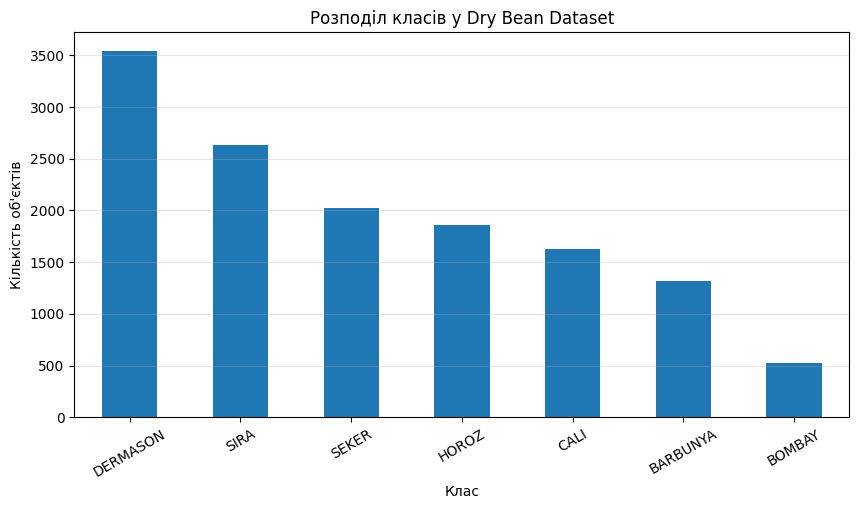

In [110]:
plt.figure(figsize=(10, 5))

df["Class"].value_counts().plot(kind="bar")

plt.xlabel("Клас")
plt.ylabel("Кількість об'єктів")
plt.title("Розподіл класів у Dry Bean Dataset")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Кореляційний аналіз

In [111]:
if not np.issubdtype(df["Class"].dtype, np.number):

    class_mapping = {
        "SEKER": 0,
        "BARBUNYA": 1,
        "BOMBAY": 2,
        "CALI": 3,
        "DERMASON": 4,
        "HOROZ": 5,
        "SIRA": 6
    }

    df["Class_numeric"] = df["Class"].map(class_mapping)

else:
    df["Class_numeric"] = df["Class"]

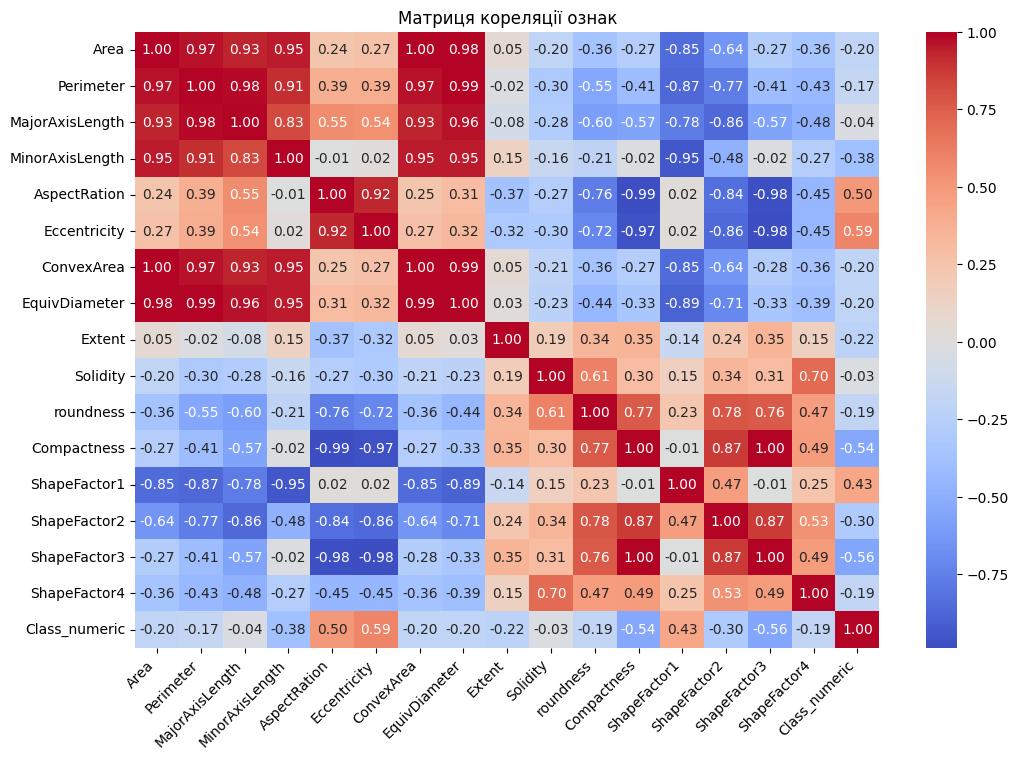

In [112]:
correlation_matrix = df.drop(columns=["Class"] ).corr()

plt.figure(figsize=(12, 8))
sns.heatmap( correlation_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", center=0)
plt.title("Матриця кореляції ознак")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

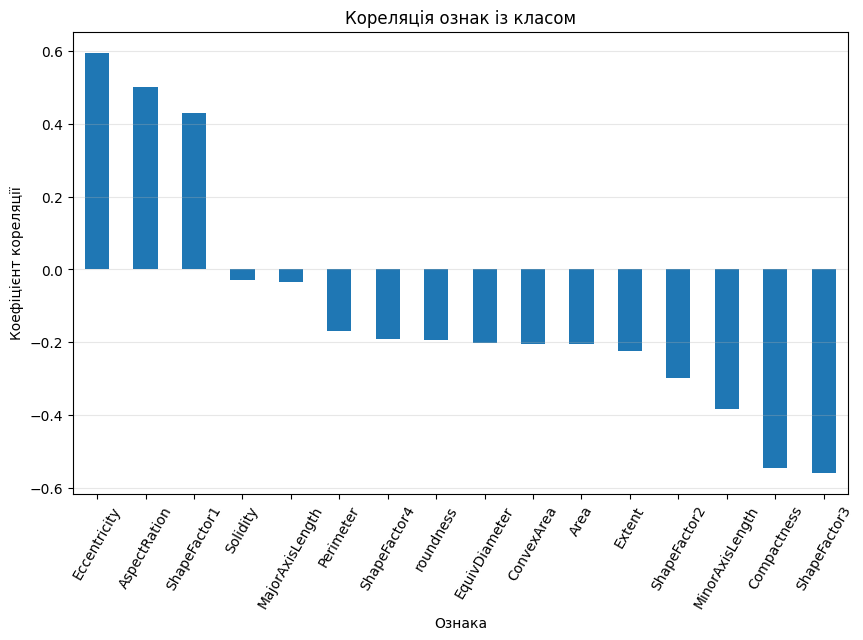

In [113]:
class_correlation = df.drop(columns=["Class"]).corr()["Class_numeric"].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
class_correlation.drop("Class_numeric").plot(kind="bar") 
plt.xlabel("Ознака")
plt.ylabel("Коефіцієнт кореляції")
plt.title("Кореляція ознак із класом")
plt.xticks(rotation=60)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Візуалізація залежності ознак від класу

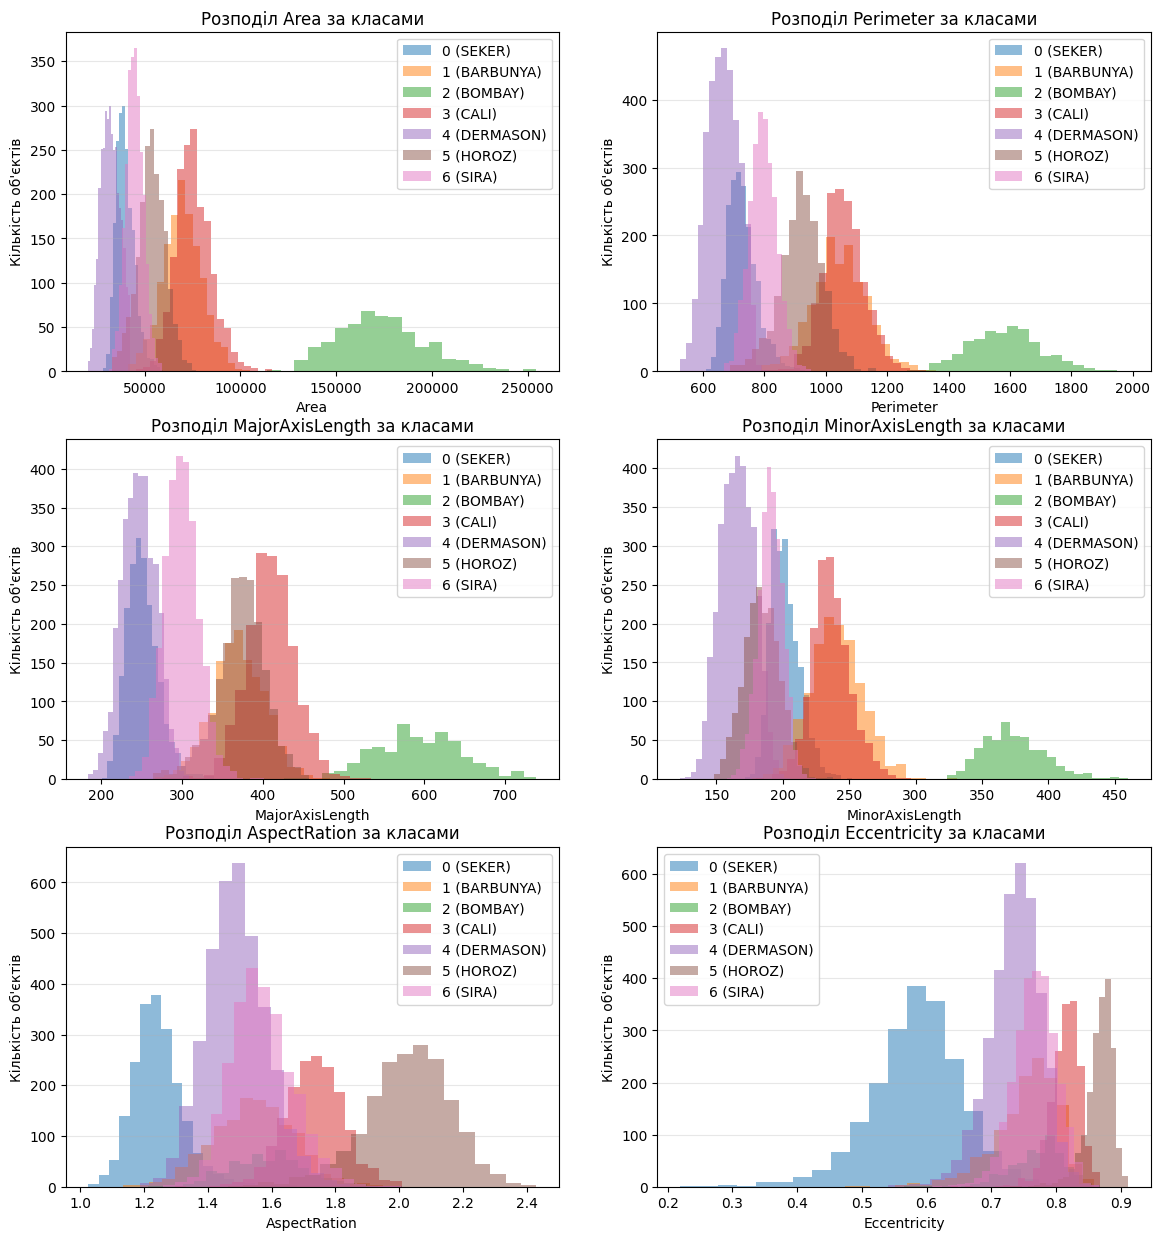

In [ ]:
features_to_plot = ["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength", "AspectRation", "Eccentricity"]
class_mapping = {0: "SEKER", 1: "BARBUNYA", 2: "BOMBAY", 3: "CALI", 4: "DERMASON", 5: "HOROZ", 6: "SIRA"}

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for ax, feature in zip(axes.ravel(), features_to_plot):

    for class_number, class_name in class_mapping.items():

        ax.hist(df[df["Class_numeric"] == class_number][feature], bins=20, alpha=0.5, label=f"{class_number} ({class_name})")

    ax.set_xlabel(feature)
    ax.set_ylabel("Кількість об'єктів")
    ax.set_title(f"Розподіл {feature} за класами")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.show()

### Підготовка X та y

In [115]:
X = df.drop(columns=["Class", "Class_numeric"]).values

y = df["Class_numeric"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13543, 16)
y shape: (13543,)


### Розділення даних на навчальну та тестову вибірки

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("Навчальна вибірка:", X_train.shape)
print("Тестова вибірка:", X_test.shape)

Навчальна вибірка: (6771, 16)
Тестова вибірка: (6772, 16)


## **2. Decision Tree**
### **2.1 Власна реалізація Decision Tree**

In [ ]:
def gini_impurity(y):

    # Check if there are no samples
    if len(y) == 0:
        return 0

    # Get class counts
    _, counts = np.unique(
        y,
        return_counts=True
    )

    # Calculate class probabilities
    probabilities = counts / len(y)

    # Calculate Gini impurity
    return 1 - np.sum(probabilities ** 2)

In [118]:
class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):

        self.feature = feature
        self.threshold = threshold

        self.left = left
        self.right = right

        self.value = value

In [ ]:
class MyDecisionTree:

    def __init__(
        self,
        max_depth=10,
        min_samples_split=2
    ):

        # Set model parameters
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None


    def fit(self, X, y):

        # Get number of classes
        self.n_classes = len(np.unique(y))

        # Build the tree
        self.root = self._grow_tree(X, y, depth=0)

        # Return the trained model
        return self


    def _grow_tree(self, X, y, depth):

        # Get number of samples and features
        n_samples, n_features = X.shape

        # Get unique classes
        unique_classes = np.unique(y)

        # Check if we should stop splitting
        if (
            depth >= self.max_depth
            or len(unique_classes) == 1
            or n_samples < self.min_samples_split
        ):

            # Create a leaf with the most common class
            leaf_value = self._most_common_class(y)

            return Node(value=leaf_value)

        # Find the best split
        best_feature, best_threshold, best_gini = (
            self._best_split(X, y)
        )

        # Check if no split was found
        if best_feature is None:

            # Create a leaf with the most common class
            leaf_value = self._most_common_class(y)

            return Node(value=leaf_value)

        # Split samples into two groups
        left_indices = (
            X[:, best_feature] <= best_threshold
        )

        right_indices = ~left_indices

        # Build the left subtree
        left_subtree = self._grow_tree(
            X[left_indices],
            y[left_indices],
            depth + 1
        )

        # Build the right subtree
        right_subtree = self._grow_tree(
            X[right_indices],
            y[right_indices],
            depth + 1
        )

        # Create a tree node
        return Node(
            feature=best_feature,
            threshold=best_threshold,
            left=left_subtree,
            right=right_subtree
        )


    def _best_split(self, X, y):

        # Get number of samples and features
        n_samples, n_features = X.shape

        # Set initial best values
        best_gini = float("inf")
        best_feature = None
        best_threshold = None

        # Calculate Gini impurity for the parent
        parent_gini = gini_impurity(y)

        # Check each feature
        for feature in range(n_features):

            # Get values of the feature
            values = X[:, feature]

            # Sort the values
            sorted_indices = np.argsort(values)

            sorted_values = values[sorted_indices]
            sorted_y = y[sorted_indices]

            # Get all classes
            classes, class_indices = np.unique(
                y,
                return_inverse=True
            )

            # Get number of classes
            n_classes = len(classes)

            # Count all classes
            total_counts = np.bincount(
                class_indices,
                minlength=n_classes
            )

            # Start with empty left group
            left_counts = np.zeros(
                n_classes,
                dtype=int
            )

            # Check possible split points
            for i in range(n_samples - 1):

                # Find the class position
                class_position = np.where(
                    classes == sorted_y[i]
                )[0][0]

                # Add the class to the left group
                left_counts[class_position] += 1

                # Skip equal values
                if (
                    sorted_values[i]
                    == sorted_values[i + 1]
                ):
                    continue

                # Count classes in the right group
                right_counts = (
                    total_counts - left_counts
                )

                # Get group sizes
                n_left = i + 1
                n_right = n_samples - n_left

                # Calculate class probabilities
                left_prob = left_counts / n_left
                right_prob = right_counts / n_right

                # Calculate left Gini impurity
                left_gini = (
                    1 - np.sum(left_prob ** 2)
                )

                # Calculate right Gini impurity
                right_gini = (
                    1 - np.sum(right_prob ** 2)
                )

                # Calculate weighted Gini impurity
                weighted_gini = (
                    (n_left / n_samples) * left_gini
                    +
                    (n_right / n_samples) * right_gini
                )

                # Check if this is the best split
                if weighted_gini < best_gini:

                    # Save the best values
                    best_gini = weighted_gini
                    best_feature = feature

                    # Calculate the split threshold
                    best_threshold = (
                        sorted_values[i]
                        + sorted_values[i + 1]
                    ) / 2

        # Check if the split improves the result
        if best_gini >= parent_gini:

            return None, None, None

        # Return the best split
        return (
            best_feature,
            best_threshold,
            best_gini
        )


    def _most_common_class(self, y):

        # Get unique classes and their counts
        values, counts = np.unique(
            y,
            return_counts=True
        )

        # Return the most common class
        return values[np.argmax(counts)]


    def _predict_sample(self, x, node):

        # Check if this is a leaf
        if node.value is not None:

            return node.value

        # Go to the left child
        if x[node.feature] <= node.threshold:

            return self._predict_sample(
                x,
                node.left
            )

        # Go to the right child
        else:

            return self._predict_sample(
                x,
                node.right
            )


    def predict(self, X):

        # Predict each sample
        return np.array([
            self._predict_sample(x, self.root)
            for x in X
        ])

In [120]:
my_tree = MyDecisionTree(
    max_depth=8,
    min_samples_split=2
)

start_time = time.time()
my_tree.fit(X_train, y_train)
my_runtime = time.time() - start_time

In [121]:
y_train_pred_my_tree = my_tree.predict(X_train)
y_test_pred_my_tree = my_tree.predict(X_test)

In [122]:
my_tree_train_accuracy = accuracy_score(y_train, y_train_pred_my_tree)
my_tree_test_accuracy = accuracy_score(y_test, y_test_pred_my_tree)

print("Train Accuracy:", my_tree_train_accuracy)
print("Test Accuracy:", my_tree_test_accuracy)
print(f"Training time: {my_runtime:.4f} s")

Train Accuracy: 0.9483089647024073
Test Accuracy: 0.8913171884229178
Training time: 35.1090 s


### **2.2 Реалізація Decision Tree за допомогою бібліотеки Scikit-learn**

In [123]:
sklearn_tree = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=2,
    random_state=42
)

start_time = time.time()
sklearn_tree.fit(X_train, y_train)
sklearn_tree_runtime = time.time() - start_time

In [124]:
y_train_pred_sklearn_tree = sklearn_tree.predict(X_train)
y_test_pred_sklearn_tree = sklearn_tree.predict(X_test)

In [125]:
sklearn_tree_train_accuracy = accuracy_score(y_train, y_train_pred_sklearn_tree)
sklearn_tree_test_accuracy = accuracy_score(y_test, y_test_pred_sklearn_tree)

print("Train Accuracy:", sklearn_tree_train_accuracy)
print("Test Accuracy:", sklearn_tree_test_accuracy)
print(f"Training time: {sklearn_tree_runtime:.4f} s")

Train Accuracy: 0.9481612760301285
Test Accuracy: 0.8935321913762552
Training time: 0.2945 s


## **3. Random Forest**
### **3.1 Власна реалізація Random Forest**

In [ ]:
class MyRandomForest:

    def __init__(
        self,
        n_estimators=100,
        max_depth=8,
        min_samples_split=2,
        max_features="sqrt",
        random_state=42
    ):

        # Set model parameters
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state

        # Store all trees
        self.trees = []

    def fit(self, X, y):

        # Set random seed
        np.random.seed(self.random_state)

        # Get number of samples and features
        n_samples, n_features = X.shape

        # Choose number of features for each tree
        if self.max_features == "sqrt":

            # Use square root of the number of features
            self.n_features_per_tree = max(
                1,
                int(np.sqrt(n_features))
            )

        elif self.max_features is None:

            # Use all features
            self.n_features_per_tree = n_features

        else:

            # Use the given number of features
            self.n_features_per_tree = self.max_features

        # Clear old trees
        self.trees = []

        # Create many trees
        for i in range(self.n_estimators):

            # Choose random samples with replacement
            sample_indices = np.random.choice(
                n_samples,
                size=n_samples,
                replace=True
            )

            # Create a new training sample
            X_sample = X[sample_indices]
            y_sample = y[sample_indices]

            # Choose random features for this tree
            feature_indices = np.random.choice(
                n_features,
                size=self.n_features_per_tree,
                replace=False
            )

            # Use only selected features
            X_sample_features = X_sample[:, feature_indices]

            # Create a decision tree
            tree = MyDecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )

            # Train the tree
            tree.fit(
                X_sample_features,
                y_sample
            )

            # Save the tree and its features
            self.trees.append(
                (tree, feature_indices)
            )

        # Return the trained model
        return self

    def predict(self, X):

        # Store predictions from all trees
        predictions = []

        # Get prediction from each tree
        for tree, feature_indices in self.trees:

            # Use the same features as during training
            X_features = X[:, feature_indices]

            # Make predictions
            tree_predictions = tree.predict(
                X_features
            )

            # Save predictions
            predictions.append(tree_predictions)

        # Convert predictions to an array
        predictions = np.array(predictions)

        # Store final predictions
        final_predictions = []

        # Find the most common prediction
        for i in range(X.shape[0]):

            # Get unique values and their counts
            values, counts = np.unique(
                predictions[:, i],
                return_counts=True
            )

            # Choose the most common value
            final_predictions.append(
                values[np.argmax(counts)]
            )

        # Return final predictions
        return np.array(final_predictions)

In [127]:
my_rf = MyRandomForest(
    n_estimators=100,
    max_depth=8,
    min_samples_split=2,
    max_features="sqrt",
    random_state=42
)

start_time = time.time()
my_rf.fit(X_train, y_train)
my_rf_runtime = time.time() - start_time

In [128]:
y_train_pred_my_rf = my_rf.predict(X_train)
y_test_pred_my_rf = my_rf.predict(X_test)

In [129]:
my_rf_train_accuracy = accuracy_score(y_train, y_train_pred_my_rf)
my_rf_test_accuracy = accuracy_score(y_test, y_test_pred_my_rf)

print("Train Accuracy:", my_rf_train_accuracy)
print("Test Accuracy:", my_rf_test_accuracy)
print(f"Training time: {my_rf_runtime:.4f} s")

Train Accuracy: 0.9342785408359179
Test Accuracy: 0.9022445363260484
Training time: 551.8129 s


### **3.2 Реалізація Random Forest за допомогою бібліотеки Scikit-learn**

In [130]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
random_forest.fit(X_train, y_train)
sklearn_rf_runtime = time.time() - start_time

In [131]:
y_train_pred_rf = random_forest.predict(X_train)
y_test_pred_rf = random_forest.predict(X_test)

In [132]:
sklearn_rf_train_accuracy = accuracy_score(y_train, y_train_pred_rf)
sklearn_rf_test_accuracy = accuracy_score(y_test, y_test_pred_rf)

print("Train Accuracy:", sklearn_rf_train_accuracy)
print("Test Accuracy:", sklearn_rf_test_accuracy)
print(f"Training time: {sklearn_rf_runtime:.4f} s")

Train Accuracy: 0.9491950967360804
Test Accuracy: 0.9156822209096279
Training time: 1.4957 s


## **4. Порівняння**

In [133]:
results = pd.DataFrame({
    "Model": [
        "My Decision Tree",
        "Scikit-learn Decision Tree",
        "My Random Forest",
        "Scikit-learn Random Forest"
    ],

    "Train Accuracy": [
        my_tree_train_accuracy,
        sklearn_tree_train_accuracy,
        my_rf_train_accuracy,
        sklearn_rf_train_accuracy
    ],

    "Test Accuracy": [
        my_tree_test_accuracy,
        sklearn_tree_test_accuracy,
        my_rf_test_accuracy,
        sklearn_rf_test_accuracy
    ],
    
    "Time": [
       my_runtime,
       sklearn_tree_runtime,
       my_rf_runtime,
       sklearn_rf_runtime
    ]
})

results

,Model,Train Accuracy,Test Accuracy,Time
0,My Decision Tree,0.948309,0.891317,35.109043
1,Scikit-learn Decision Tree,0.948161,0.893532,0.294487
2,My Random Forest,0.934279,0.902245,551.812948
3,Scikit-learn Random Forest,0.949195,0.915682,1.495660


### Порівняння точності моделей

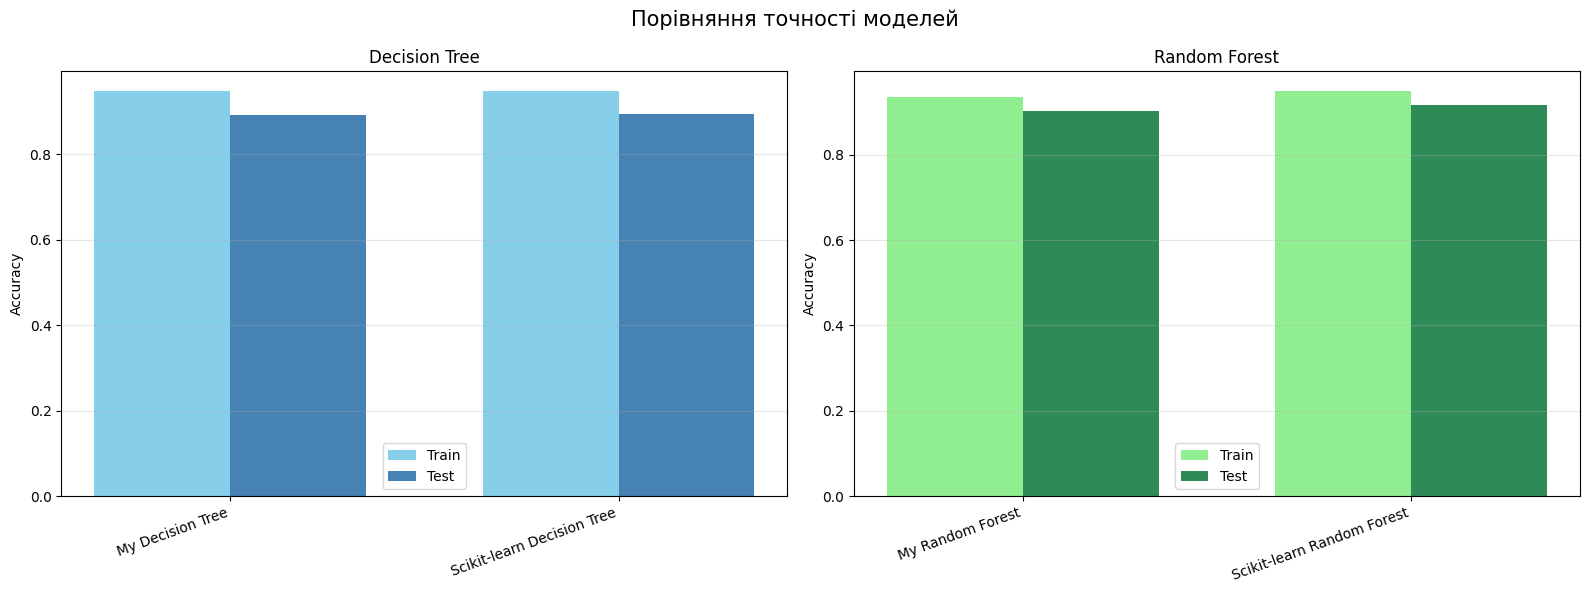

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(2)

axes[0].bar(x - 0.35 / 2, [my_tree_train_accuracy, sklearn_tree_train_accuracy], 0.35, color="skyblue", label="Train")
axes[0].bar(x + 0.35 / 2, [my_tree_test_accuracy, sklearn_tree_test_accuracy], 0.35, color="steelblue", label="Test")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["My Decision Tree", "Scikit-learn Decision Tree"], rotation=20, ha="right")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Decision Tree")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x - 0.35 / 2, [my_rf_train_accuracy, sklearn_rf_train_accuracy], 0.35, color="lightgreen", label="Train")
axes[1].bar(x + 0.35 / 2, [my_rf_test_accuracy, sklearn_rf_test_accuracy], 0.35, color="seagreen", label="Test")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["My Random Forest", "Scikit-learn Random Forest"], rotation=20, ha="right")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Random Forest")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Порівняння точності моделей", fontsize=15)
plt.tight_layout()
plt.show()

### Порівняння матриць помилок Decision Tree та Random Forest

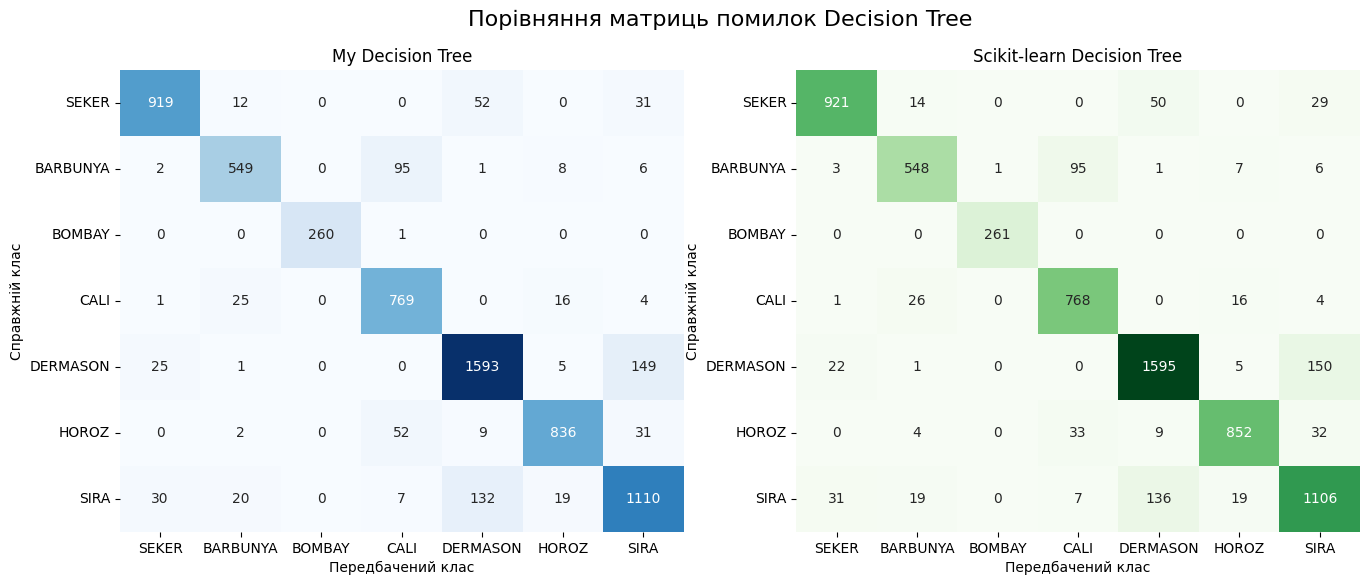

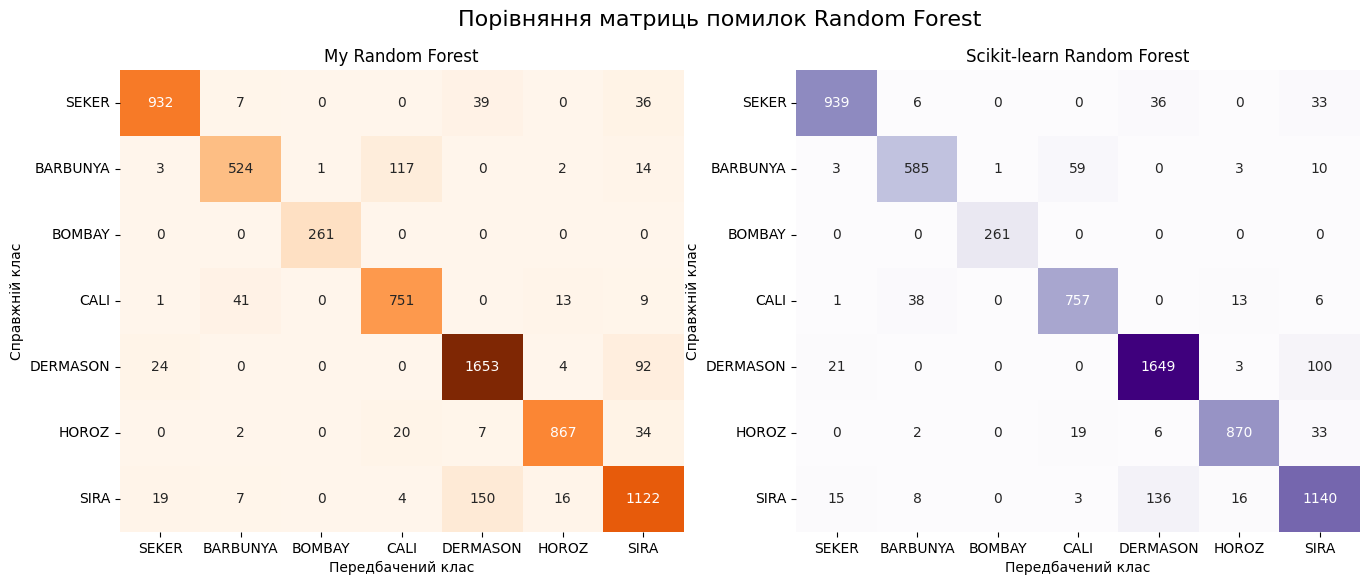

In [135]:
cm_my_tree = confusion_matrix(y_test, y_test_pred_my_tree)
cm_sklearn_tree = confusion_matrix(y_test, y_test_pred_sklearn_tree)
cm_my_rf = confusion_matrix(y_test, y_test_pred_my_rf)
cm_sklearn_rf = confusion_matrix(y_test, y_test_pred_rf)

class_names = ["SEKER", "BARBUNYA", "BOMBAY", "CALI", "DERMASON", "HOROZ", "SIRA"]

fig, axes = plt.subplots( 1, 2, figsize=(16, 6))

sns.heatmap(cm_my_tree, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axes[0], cbar=False)
sns.heatmap(cm_sklearn_tree, annot=True, fmt="d", cmap="Greens", xticklabels=class_names, yticklabels=class_names, ax=axes[1], cbar=False)

axes[0].set_title("My Decision Tree")
axes[0].set_xlabel("Передбачений клас")
axes[0].set_ylabel("Справжній клас")
axes[1].set_title("Scikit-learn Decision Tree")
axes[1].set_xlabel("Передбачений клас")
axes[1].set_ylabel("Справжній клас")

plt.suptitle("Порівняння матриць помилок Decision Tree", fontsize=16)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_my_rf, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names, ax=axes[0], cbar=False)
sns.heatmap(cm_sklearn_rf, annot=True, fmt="d", cmap="Purples", xticklabels=class_names, yticklabels=class_names, ax=axes[1], cbar=False)

axes[0].set_title("My Random Forest")
axes[0].set_xlabel("Передбачений клас")
axes[0].set_ylabel("Справжній клас")
axes[1].set_title("Scikit-learn Random Forest")
axes[1].set_xlabel("Передбачений клас")
axes[1].set_ylabel("Справжній клас")

plt.suptitle("Порівняння матриць помилок Random Forest", fontsize=16)
plt.show()

### Порівняння часу навчання

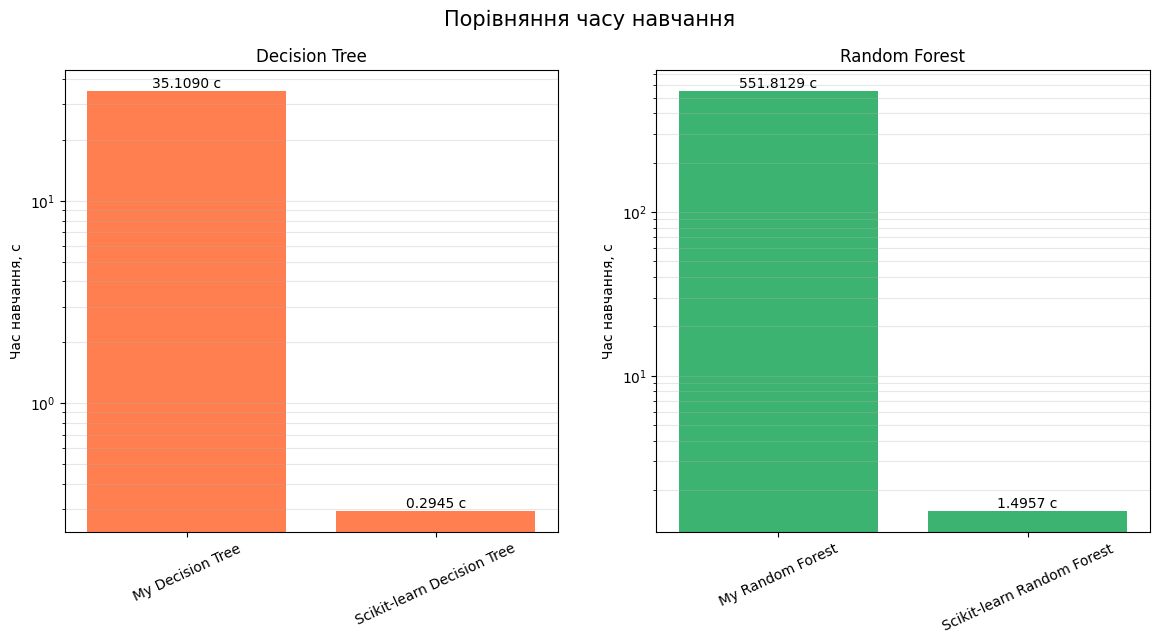

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

tree_models = ["My Decision Tree", "Scikit-learn Decision Tree"]
tree_times = [my_runtime, sklearn_tree_runtime]
bars_tree = axes[0].bar(tree_models, tree_times, color="coral")

axes[0].set_title("Decision Tree")
axes[0].set_ylabel("Час навчання, с")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.3, which="both")

for bar, value in zip(bars_tree, tree_times):

    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f} с",
        ha="center",
        va="bottom"
    )

rf_models = ["My Random Forest", "Scikit-learn Random Forest"]
rf_times = [my_rf_runtime, sklearn_rf_runtime]
bars_rf = axes[1].bar(rf_models, rf_times, color="mediumseagreen")

axes[1].set_title("Random Forest")
axes[1].set_ylabel("Час навчання, с")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.3, which="both")

for bar, value in zip(bars_rf, rf_times):

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f} с",
        ha="center",
        va="bottom"
    )

plt.suptitle("Порівняння часу навчання", fontsize=15)
plt.show()